In [135]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import numpy as np

In [136]:
clean_data = "data\\processed\\captures1_v2\\clean\\MODBUS_ONLY_eth2dump-clean-1h_1.csv"
mitm_data = "data\\processed\\captures1_v2\\mitm\\MODBUS_ONLY_eth2dump-mitm-change-5m-1h_1.csv"

absolute_clean_path = (Path("../..") / clean_data).resolve()
absolute_mitm_path = (Path("../..") / mitm_data).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_clean_path)
print("Absolute path to mitm data:", absolute_mitm_path)

Absolute path to clean data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\clean\MODBUS_ONLY_eth2dump-clean-1h_1.csv
Absolute path to mitm data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\mitm\MODBUS_ONLY_eth2dump-mitm-change-5m-1h_1.csv


In [137]:
clean_data = pd.read_csv(absolute_clean_path)
mitm_data = pd.read_csv(absolute_mitm_path)

print(clean_data.columns.tolist())
display(clean_data.head())
print(f"Length of MITM data: {len(mitm_data)}")

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'inter_arrival_time', 'time_from_start', 'rolling_iat_mean', 'rolling_iat_std', 'requests_per_second', 'flow_id', 'flow_pkt_count', 'unique_func_codes', 'round_trip_time']


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,transaction_id,...,function_name,inter_arrival_time,time_from_start,rolling_iat_mean,rolling_iat_std,requests_per_second,flow_id,flow_pkt_count,unique_func_codes,round_trip_time
0,3,1.536440e+09,2018-09-08T16:54:30.205937,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,NaN,0.000000,NaN,NaN,1,172.27.224.250_172.27.224.70,1,1,0.003102
1,4,1.536440e+09,2018-09-08T16:54:30.209039,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.003102,0.003102,0.003102,NaN,1,172.27.224.250_172.27.224.70,2,1,0.003102
2,6,1.536440e+09,2018-09-08T16:54:30.517529,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.308490,0.311592,0.155796,0.215942,2,172.27.224.250_172.27.224.70,3,1,0.010858
3,7,1.536440e+09,2018-09-08T16:54:30.528387,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.010858,0.322450,0.107483,0.174120,2,172.27.224.250_172.27.224.70,4,1,0.010858
4,10,1.536440e+09,2018-09-08T16:54:30.829737,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.301350,0.623800,0.155950,0.172070,3,172.27.224.250_172.27.224.70,5,1,0.009315


Length of MITM data: 23283


In [138]:
# Volatility Change Detector Class
class VolatilityChangeDetector:
    def __init__(self, baseline_window=50, threshold=3):
        self.baseline_window = baseline_window
        self.threshold = threshold
        self.baseline_mean = None
        self.baseline_std = None
        
    def fit(self, data):
        """Train on baseline (normal) data"""
        self.baseline_mean = np.mean(data)
        self.baseline_std = np.std(data)
        return self
    
    def detect(self, data):
        """Detect anomalies based on baseline"""
        z_scores = np.abs((data - self.baseline_mean) / self.baseline_std)
        return z_scores > self.threshold

In [139]:
start = 0
end = 7000 # len(mitm_data)

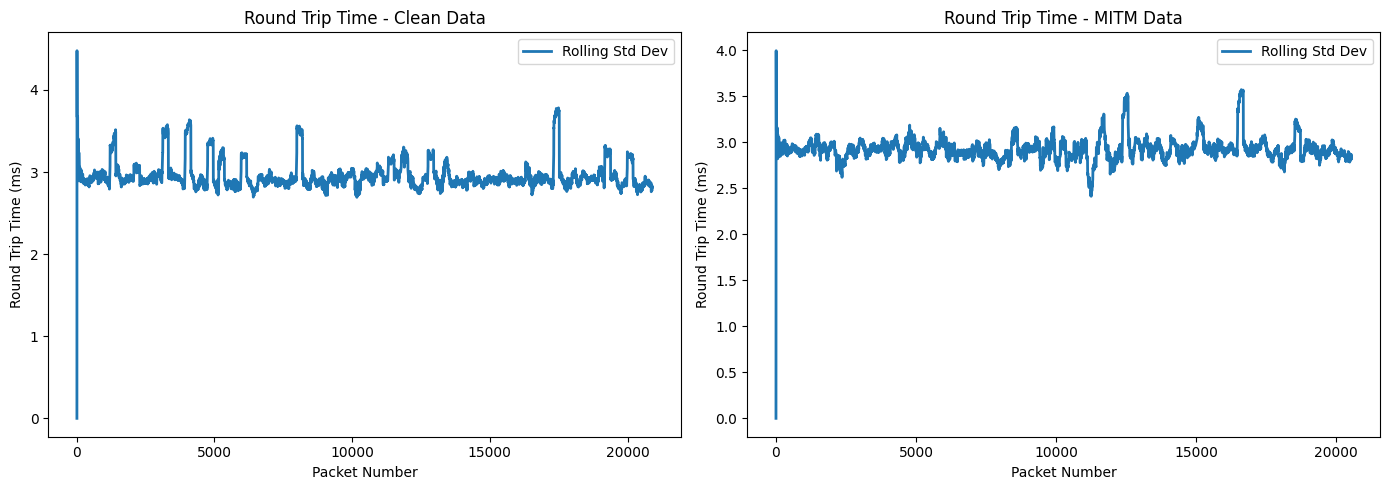

In [140]:
# Set rolling window size
window_size = 75

# Convert seconds to milliseconds
clean_data['round_trip_time'] = clean_data['round_trip_time'] * 1000
mitm_data['round_trip_time'] = mitm_data['round_trip_time'] * 1000

# Calculate rolling averages
clean_data['rtt_rolling_avg'] = clean_data['round_trip_time'].rolling(window=window_size, min_periods=1).mean()
mitm_data['rtt_rolling_avg'] = mitm_data['round_trip_time'].rolling(window=window_size, min_periods=1).mean()

# Calculate rolling std deviations
clean_data['rtt_rolling_std'] = clean_data['round_trip_time'].rolling(window=window_size, min_periods=1).std()
mitm_data['rtt_rolling_std'] = mitm_data['round_trip_time'].rolling(window=window_size, min_periods=1).std()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data with rolling standard deviation
subset_clean = clean_data.iloc[start:end] # Use the defined start and end
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')
ax1.legend()

# Plot MITM data with rolling standard deviation
subset_mitm = mitm_data.iloc[start:end] # Use the defined start and end
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')
ax2.legend()

plt.tight_layout()
plt.show()

In [141]:
# Volatility Change Detector Class
class VolatilityChangeDetector:
    def __init__(self, baseline_window=50, threshold=3):
        self.baseline_window = baseline_window
        self.threshold = threshold
        self.baseline_mean = None
        self.baseline_std = None
        
    def fit(self, data):
        """Train on baseline (normal) data"""
        self.baseline_mean = np.mean(data)
        self.baseline_std = np.std(data)
        return self
    
    def detect(self, data):
        """Detect anomalies based on baseline"""
        z_scores = np.abs((data - self.baseline_mean) / self.baseline_std)
        return z_scores > self.threshold

In [142]:
start = 500
end = 7000 # len(mitm_data)

subset_clean = clean_data.iloc[start:end] # Use the defined start and end
subset_mitm = mitm_data.iloc[start:end] # Use the defined start and end

print(f"Clean subset length: {len(subset_clean)}")
print(f"MITM subset length: {len(subset_mitm)}")

Clean subset length: 6500
MITM subset length: 6500


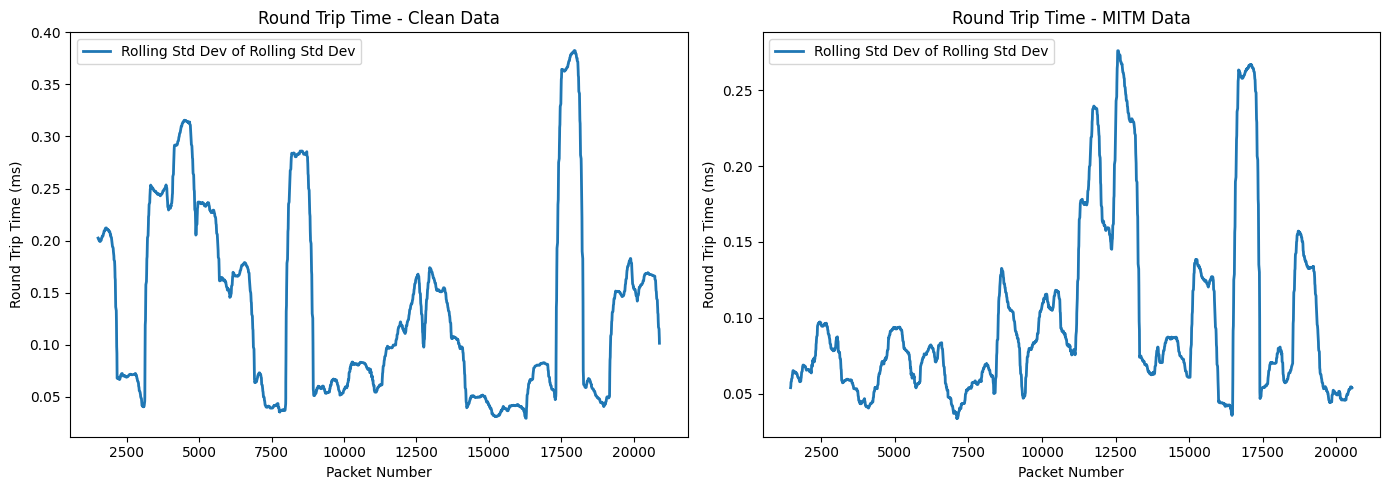

In [143]:
window_size = 250
threshold = 0.5

clean_data['rtt_rolling_std_std'] = clean_data['rtt_rolling_std'].rolling(window=window_size, min_periods=1).std()
mitm_data['rtt_rolling_std_std'] = mitm_data['rtt_rolling_std'].rolling(window=window_size, min_periods=1).std()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data with rolling standard deviation
subset_clean = clean_data.iloc[start:end] # Use the defined start and end
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_std_std'], linewidth=2, label='Rolling Std Dev of Rolling Std Dev')
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')
ax1.legend()

# Plot MITM data with rolling standard deviation
subset_mitm = mitm_data.iloc[start:end] # Use the defined start and end
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_std_std'], linewidth=2, label='Rolling Std Dev of Rolling Std Dev')
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')
ax2.legend()

plt.tight_layout()
plt.show()


